In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# J < 0: Ferromagnetic, J > 0: Antiferromagnetic
# Takes a configuration and the coefficient J and computes the energy.
def energy(conf, J, B):
    X, Y = conf.shape
    E = 0
    for x1 in range(X):
        for y1 in range(Y):
            E += B*conf[x1,y1]
            for x2 in range(x1+1, X):
                for y2 in range(y1+1, Y):
                    E += J*conf[x1,y1]*conf[x2,y2]
    return E

# Computes the variation in energy for a spin flip given the configuration
# and the coordinates of the flipping site.
def calc_dE(conf, x, y, J, B):
    X, Y = conf.shape
    dE = 0
    dE += 2*B*conf[x,y]
    for x1 in range(X):
        for y1 in range(Y):
            if x1==x and y1==y:
                continue
            dE += 2*J*conf[x,y]*conf[x1,y1]
    return dE


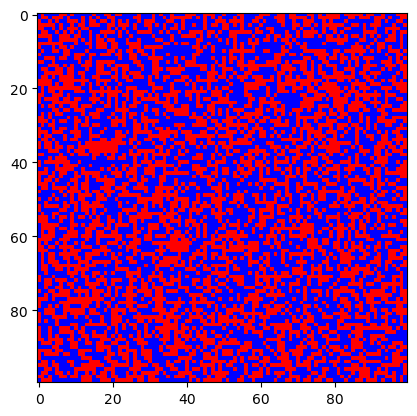

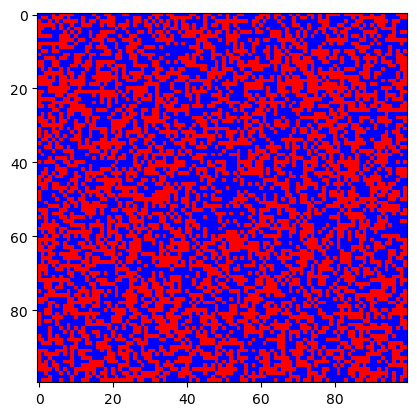

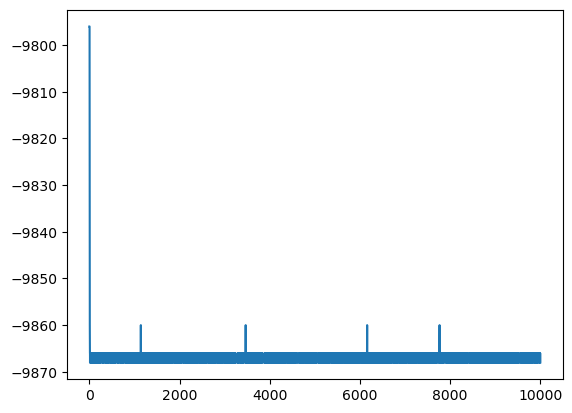

In [9]:
X = 100
Y = 100
J = -1
B = 10
T = 1 # temperature

# Initial state
conf = np.random.choice([1,-1], (X,Y))
conf[20,20]=-1

# Initial energy
E = energy(conf, J, B)
Es = [E] # we track the evolution of the energy

# Plot initial state
#plt.figure(figsize=(10, 10))
plt.imshow(conf, cmap='bwr', interpolation='none')
plt.show()

# We apply the metropolis algorithm N times
N = 10000
for i in range(N):
    # A site is chosen at random
    x = np.random.randint(0, X)
    y = np.random.randint(0, Y)

    # Compute the change in energy if we flip that site
    dE = calc_dE(conf, x, y, J, B)
    # Transition probability
    p = np.exp(-dE/T)
    # If the energy decreases, the site flips
    if dE <= 0:
        conf[x,y] = -conf[x,y]
        E += dE
    # If the energy increases, the site flips with probability p.
    elif np.random.rand() <= p:
            conf[x,y] = -conf[x,y]
            E += dE
    '''
    # This version flips always with probability p.
    if np.random.rand() <= p:
        conf[x,y] = -conf[x,y]
        E += dE
    '''
    Es.append(E)
        
#plt.figure(figsize=(10, 10))
plt.imshow(conf, cmap='bwr', interpolation='none')
plt.show()
plt.plot(Es)

plt.show()

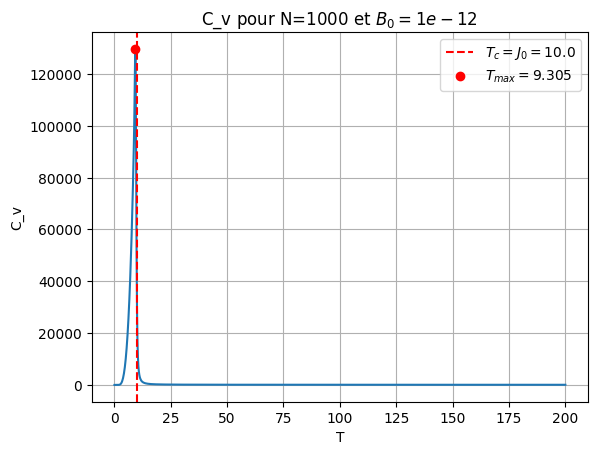

In [32]:
from scipy.special import logsumexp, comb
    

#Z_N exact
def Z_N_exact_log(N):
    k = np.arange(0, N+1)
    x = k / N
    log_terms = np.log(comb(N, k)) + N * (J0*(2*x-1)**2 + 2*B0*(2*x-1)) / (2*T)
    Z_N_log = -J0/(2*T) + logsumexp(log_terms)
    return Z_N_log


#dZ/dbeta = - U enegie moyenne
def U(N, beta, J0, B0):
    k = np.arange(0, N+1)
    x = k / N
    E = N * (J0*(2*x - 1)**2 + 2*B0*(2*x - 1))
    log_pk = np.log(comb(N, k)) + 1/2 * beta * E
    logZ_sum = logsumexp(log_pk)
    log_num = logsumexp(log_pk + np.log(E))

    dZ = -J0/2 + 1/2 * np.exp(log_num - logZ_sum)
    return - dZ


#Cv = dU_ dT = d2lnZ/dbeta2 = beta**2 * variance  = capacité

def Cv(N, beta, J0, B0):
    k = np.arange(0, N+1)
    x = k / N
    E = N * (J0 * (2*x - 1)**2 + 2 * B0 * (2*x - 1))
    log_pk = np.log(comb(N, k)) + 0.5 * beta * E
    logZ_sum = logsumexp(log_pk)
    p = np.exp(log_pk - logZ_sum)   
    esperance_E = np.sum(p * E)
    esperance_Ecarre = np.sum(p * (E**2))
    var_E = esperance_Ecarre - esperance_E**2

    d2Z = 1/4 * var_E
    return d2Z

fig = plt.figure()

N = 1000
J0 = 10
B0 = 10**(-12)
T = np.linspace(0.1, 200, 1000)
Beta = 1.0 / T

T_critique = J0

Y = [Cv(N, beta, J0, B0) for beta in Beta]
plt.plot(T, Y)

plt.axvline(x=T_critique, color='red', linestyle='--', label=f'$T_c = J_0 = {J0:.1f}$')

max_Cv_index = np.argmax(Y)
T_max_Cv = T[max_Cv_index]
Cv_max = Y[max_Cv_index]
plt.plot(T_max_Cv, Cv_max, 'o', color='red',
         label=f'$T_{{max}} = {T_max_Cv:.3f}$')



plt.xlabel('T')
plt.ylabel('C_v')
plt.title(f'C_v pour N={N} et $B_0={B0:.0e}$')
plt.grid(True)
plt.legend()
plt.show()



On devrait avoir $T_c = T_{max}$ pour N grand mais avec log Zn exact on peut pas aller bien loin dans les N. 


Si on utilise l'approximation phi_max : 


C:\Users\apeti\AppData\Local\Temp\ipykernel_42452\2434615892.py:18: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_solution = fsolve(h, initial_guess, args=(T, J0, B0))


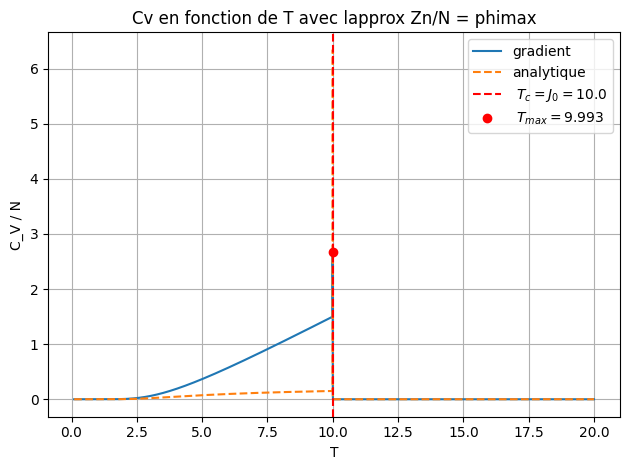

In [31]:
from scipy.optimize import fsolve

J0 = 10       
B0 = 1e-12     
T_critique = J0

# On cherche saddle point

def h(m, T, J0, B0):
    return m - np.tanh((J0 * m + B0) / T)

def trouve_saddle(T, J0, B0):
    if T > J0:
        initial_guess = 0.01 
    else:
        initial_guess = np.sqrt(1 - T / J0) 
        
    m_solution = fsolve(h, initial_guess, args=(T, J0, B0))
    return np.abs(m_solution[0])

def Cv_saddle_point_grad(m_values, T_values, J0, B0):
    #on divise par N, comme ça on n'a plus de dépendance en N
    U_sur_N = -J0 * m_values**2 / 2 - B0 * m_values #energie moyenne
    dU_dT_sur_N = np.gradient(U_sur_N, T_values) #cv
    return dU_dT_sur_N 

def Cv_saddle_point_analytique(m, T, J0, B0):
    if T == 0 or np.abs(1 - J0/T * (1 - m**2)) < 1e-6:
        return np.nan 
    num = (J0 * m + B0)**2 * (1 - m**2)
    den = T**3 * (1 - (J0/T) * (1 - m**2))
    return np.abs(num / den)




T = np.linspace(0.1, 20, 10000)

M = np.array([trouve_saddle(T, J0, B0) for T in T])


CV_SP = Cv_saddle_point_grad(M, T, J0, B0)

CV_per_N = np.array([Cv_saddle_point_analytique(M[i], T[i], J0, B0) 
                     for i in range(10000)])


fig = plt.figure()
plt.plot(T, CV_SP, label = 'gradient')
plt.plot(T, CV_per_N, '--', label = 'analytique')

plt.axvline(x=T_critique, color='red', linestyle='--', label=f' $T_c = J_0 = {J0:.1f}$')

max_Cv_index = np.argmax(CV_SP)
T_max_Cv = T[max_Cv_index]
Cv_max = CV_SP[max_Cv_index]
plt.plot(T_max_Cv, Cv_max, 'o', color='red', label=f' $T_{{max}} = {T_max_Cv:.3f}$')

plt.xlabel('T')
plt.ylabel('C_V / N')
plt.title('Cv en fonction de T avec lapprox Zn/N = phimax')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

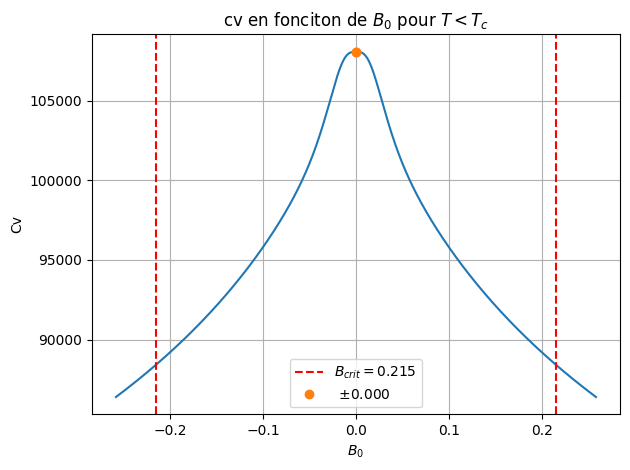

In [ ]:
#on fixe la température et on trace la capacité calorifique en fonction de B0
T = 0.9 * J0 
Beta = 1.0 / T

B_crit = T * np.arctanh(np.sqrt(1 - T / J0)) - J0 * np.sqrt(1 - T / J0)
B_crit_abs = np.abs(B_crit)

B_min = -1.2 * B_crit_abs
B_max = 1.2 * B_crit_abs
B0_values = np.linspace(B_min, B_max, 1000)

CV_B = [ Cv(N, Beta, J0, B0) for B0 in B0_values ]

fig = plt.figure()

plt.plot(B0_values, CV_B)

plt.axvline( x = B_crit_abs, color='red', linestyle='--', label=f'$B_{{crit}} = {B_crit_abs:.3f}$')
plt.axvline( x = - B_crit_abs, color='red', linestyle='--')

max_Cv_index_pos = np.argmax(CV_B[:1000//2]) 
max_Cv_index_neg = np.argmax(CV_B[1000//2:]) + 1000//2 

T_max_B0_pos = B0_values[max_Cv_index_neg] 
T_max_B0_neg = B0_values[max_Cv_index_pos] 

plt.plot([T_max_B0_pos, T_max_B0_neg], [CV_B[max_Cv_index_neg], CV_B[max_Cv_index_pos]], 
         'o', label=f' $\\pm${np.abs(T_max_B0_pos):.3f}')

plt.xlabel('$B_0$')
plt.ylabel('Cv')
plt.title(f'cv en fonciton de $B_0$ pour $T < T_c$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()